In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_safety_incidents,load_trips,load_maintenance_records, load_routes, load_loads

Path to dataset files: C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1


In [2]:
# Set the default figure size
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(color_codes = True)
pd.set_option('display.width', 1200)
pd.set_option('display.max_columns', None)

In [3]:
safety_df = load_safety_incidents()
trips_df = load_trips()
maintenance_df = load_maintenance_records()
loads_df = load_loads()
routes_df = load_routes()

In [4]:
safety_df['incident_date']=pd.to_datetime(safety_df['incident_date'])
safety_df['year']=pd.to_datetime(safety_df['incident_date']).dt.year
safety_df['month_year']=pd.to_datetime(safety_df['incident_date']).dt.to_period('M')

In [5]:
trips_df['dispatch_date']=pd.to_datetime(trips_df['dispatch_date'])
trips_df['year']=pd.to_datetime(trips_df['dispatch_date']).dt.year
trips_df['month_year']=pd.to_datetime(trips_df['dispatch_date']).dt.to_period('M')

In [6]:
maintenance_df['maintenance_date']=pd.to_datetime(maintenance_df['maintenance_date'])
maintenance_df['year']=pd.to_datetime(maintenance_df['maintenance_date']).dt.year
maintenance_df['month_year']=pd.to_datetime(maintenance_df['maintenance_date']).dt.to_period('M')

In [7]:
yearly_incidents = (
    safety_df.groupby('year')['incident_id']
    .count()
    .reset_index()
)

In [8]:
yearly_trips = (
    trips_df.groupby('year')['trip_id']
    .count()
    .reset_index()
)
yearly_miles = (
    trips_df.groupby('year')['actual_distance_miles']
    .sum()
    .reset_index()
)

In [9]:
yearly_maintenance_records = (
    maintenance_df.groupby('year')['maintenance_id']
    .count()
    .reset_index()
)
scheduled_df = maintenance_df[maintenance_df['service_description'].str.contains('Scheduled', case=False, na=False)]

In [10]:
from IPython.display import HTML, display

def show_wide_style(df):
    html = df.to_html(index=False)
    display(HTML(f"""
    <div style="width:100%; overflow-x:auto;">
      <div style="min-width:max-content;">
        {html}
      </div>
    </div>
    """))

In [11]:
#  Use a simpler approach to build the summary
def get_count(keyword):
    # This searches for the keyword anywhere in the description
    mask = scheduled_df['service_description'].str.contains(keyword, case=False, na=False)
    return scheduled_df[mask].groupby('year')['maintenance_id'].count()

#  Rebuild the table
summary_scheduled_df = pd.DataFrame({
    'scheduled_tires': get_count('Tire'),
    'scheduled_brake': get_count('Brake'),
    'scheduled_preventative': get_count('Prevent'), # Shortened to catch 'Preventative' or 'Preventive'
    'scheduled_engine': get_count('Engine')
}).reset_index()

print(summary_scheduled_df)


   year  scheduled_tires  scheduled_brake  scheduled_preventative  scheduled_engine
0  2022               60               42                      41                53
1  2023               49               47                      51                49
2  2024               38               51                      52                50


<div style="font-size:20px; font-weight:bold;"> Scheduled Maintenance Records (2022 - 2024)</div>

In [12]:
show_wide_style(summary_scheduled_df.style.hide(axis="index"))

year,scheduled_tires,scheduled_brake,scheduled_preventative,scheduled_engine
2022,60,42,41,53
2023,49,47,51,49
2024,38,51,52,50


In [13]:
# 1. Clean the original data safely
maintenance_df.loc[:, 'service_description'] = maintenance_df['service_description'].str.strip()

# 2. Define your keywords (renamed column headers to reflect 'emergency')
keywords = {
    'emergency_tires': 'Tire',
    'emergency_brake': 'Brake',
    'emergency_preventative': 'Prevent',
    'emergency_engine': 'Engine',
    'emergency_transmission': 'Transmission'
}

# 3. Build the summary by filtering for 'Emergency' + Keyword
summary_data = []
for col_name, key in keywords.items():
    # Swapped 'Scheduled' for 'Emergency'
    mask = (maintenance_df['service_description'].str.contains('Emergency', case=False, na=False)) & \
           (maintenance_df['service_description'].str.contains(key, case=False, na=False))
    
    counts = maintenance_df[mask].groupby('year')['maintenance_id'].count().reset_index(name=col_name)
    summary_data.append(counts)

# 4. Merge all summaries on 'year'
from functools import reduce
summary_emergency_df = reduce(lambda left, right: pd.merge(left, right, on='year', how='outer'), summary_data).fillna(0)

print(summary_emergency_df)


   year  emergency_tires  emergency_brake  emergency_preventative  emergency_engine  emergency_transmission
0  2022               57               50                      50                47                      46
1  2023               43               49                      47                41                      50
2  2024               39               42                      34                41                      46


<div style="font-size:20px; font-weight:bold;"> Emergency Maintenance Records (2022 - 2024)</div>

In [14]:
show_wide_style(summary_emergency_df.style.hide(axis="index"))

year,emergency_tires,emergency_brake,emergency_preventative,emergency_engine,emergency_transmission
2022,57,50,50,47,46
2023,43,49,47,41,50
2024,39,42,34,41,46


In [15]:
# 1. Clean the original data safely
maintenance_df.loc[:, 'service_description'] = maintenance_df['service_description'].str.strip()

# 2. Define keywords (renamed column headers to reflect 'routine')
keywords = {
    'routine_tires': 'Tire',
    'routine_brake': 'Brake',
    'routine_preventative': 'Prevent',
    'routine_engine': 'Engine',
    'routine_transmission': 'Transmission'
}

# 3. Build the summary by filtering for 'Routine' + Keyword
summary_data = []
for col_name, key in keywords.items():
    # Swapped 'Emergency' for 'Routine'
    mask = (maintenance_df['service_description'].str.contains('Routine', case=False, na=False)) & \
           (maintenance_df['service_description'].str.contains(key, case=False, na=False))
    
    counts = maintenance_df[mask].groupby('year')['maintenance_id'].count().reset_index(name=col_name)
    summary_data.append(counts)

# 4. Merge all summaries on 'year'
from functools import reduce
summary_routine_df = reduce(lambda left, right: pd.merge(left, right, on='year', how='outer'), summary_data).fillna(0)

print(summary_routine_df)


   year  routine_tires  routine_brake  routine_preventative  routine_engine  routine_transmission
0  2022             48             34                    47              43                    37
1  2023             43             43                    48              51                    53
2  2024             37             44                    52              40                    42


<div style="font-size:20px; font-weight:bold;">
  Routine Maintenance Records (2022–2024)
</div>

In [16]:
show_wide_style(summary_routine_df.style.hide(axis="index"))

year,routine_tires,routine_brake,routine_preventative,routine_engine,routine_transmission
2022,48,34,47,43,37
2023,43,43,48,51,53
2024,37,44,52,40,42


Scheduled Tires: Dropped from 60 in 2022 to 38 in 2024 (a 36.7% decrease).

Emergency Tires: Dropped from 57 in 2022 to 39 in 2024 (a 31.6% decrease).

Routine Tires: Dropped from 48 in 2022 to 37 in 2024 (a 22.9% decrease).

In [17]:
incidents_df = safety_df.merge(trips_df, on='trip_id', how='inner')
incidents_df.loc[
    incidents_df['truck_id_x'].isna() &
    incidents_df['truck_id_y'].isna()
]


,incident_id,trip_id,truck_id_x,driver_id_x,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description,year_x,month_year_x,load_id,driver_id_y,truck_id_y,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,year_y,month_year_y
59,INC00000060,TRIP00067707,NaN,DRV00101,2024-05-21 07:00:00,Accident,Atlanta,IL,True,False,13414.05,0.0,13414.05,False,Severe incident involving equipment,2024,2024-05,LOAD00067707,DRV00101,NaN,TRL00044,2024-05-19,1127,19.6,156.3,7.21,9.1,Completed,2024,2024-05


In [18]:
incidents_df = (
    incidents_df
        .drop(columns=['truck_id_y'])
        .rename(columns={'truck_id_x': 'truck_id'})
)

In [19]:
incidents_df = incidents_df.merge(maintenance_df, on='truck_id', how='inner')

In [20]:
incidents_df.head()

,incident_id,trip_id,truck_id,driver_id_x,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description,year_x,month_year_x,load_id,driver_id_y,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,year_y,month_year_y,maintenance_id,maintenance_date,maintenance_type,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,facility_location,downtime_hours,service_description,year,month_year
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,DRV00006,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000036,2022-01-12,Engine,183616,1.5,129.95,2094.46,2224.41,Detroit,36.5,Routine Engine,2022,2022-01
1,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,DRV00006,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000044,2022-01-14,Engine,629714,4.2,386.73,1058.81,1445.54,Denver,23.1,Routine Engine,2022,2022-01
2,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,DRV00006,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000047,2022-01-15,Inspection,678182,1.8,216.90,124.70,341.60,Milwaukee,17.6,Scheduled Inspection,2022,2022-01
3,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,DRV00006,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000050,2022-01-17,Repair,615274,2.8,343.60,1866.29,2209.89,Salt Lake City,3.4,Emergency Repair,2022,2022-01
4,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,DRV00006,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000119,2022-02-12,Tire,567636,7.9,719.89,3334.38,4054.27,Los Angeles,36.9,Scheduled Tire,2022,2022-02


In [21]:
mismatch = incidents_df[
    incidents_df['driver_id_x'].notna() &
    incidents_df['driver_id_y'].notna() &
    (incidents_df['driver_id_x'] != incidents_df['driver_id_y'])
]

len(mismatch)

0

In [22]:
incidents_df = incidents_df.drop(columns=['driver_id_y']).rename(columns={'driver_id_x': 'driver_id'})


In [23]:
incidents_df.head()

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description,year_x,month_year_x,load_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,year_y,month_year_y,maintenance_id,maintenance_date,maintenance_type,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,facility_location,downtime_hours,service_description,year,month_year
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000036,2022-01-12,Engine,183616,1.5,129.95,2094.46,2224.41,Detroit,36.5,Routine Engine,2022,2022-01
1,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000044,2022-01-14,Engine,629714,4.2,386.73,1058.81,1445.54,Denver,23.1,Routine Engine,2022,2022-01
2,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000047,2022-01-15,Inspection,678182,1.8,216.90,124.70,341.60,Milwaukee,17.6,Scheduled Inspection,2022,2022-01
3,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000050,2022-01-17,Repair,615274,2.8,343.60,1866.29,2209.89,Salt Lake City,3.4,Emergency Repair,2022,2022-01
4,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,2023,2023-04,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,2023,2023-04,MAINT00000119,2022-02-12,Tire,567636,7.9,719.89,3334.38,4054.27,Los Angeles,36.9,Scheduled Tire,2022,2022-02


In [24]:
pairs = {
    'incident_year': ('year_x', 'year_y'),
    'incident_month_year': ('month_year_x', 'month_year_y'),
}

for new_col, (col_x, col_y) in pairs.items():
    incidents_df[new_col] = incidents_df[col_x].combine_first(incidents_df[col_y])

incidents_df = incidents_df.drop(
    columns=[c for pair in pairs.values() for c in pair]
)

In [25]:
incidents_df.head()

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description,load_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,maintenance_id,maintenance_date,maintenance_type,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,facility_location,downtime_hours,service_description,year,month_year,incident_year,incident_month_year
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000036,2022-01-12,Engine,183616,1.5,129.95,2094.46,2224.41,Detroit,36.5,Routine Engine,2022,2022-01,2023,2023-04
1,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000044,2022-01-14,Engine,629714,4.2,386.73,1058.81,1445.54,Denver,23.1,Routine Engine,2022,2022-01,2023,2023-04
2,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000047,2022-01-15,Inspection,678182,1.8,216.90,124.70,341.60,Milwaukee,17.6,Scheduled Inspection,2022,2022-01,2023,2023-04
3,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000050,2022-01-17,Repair,615274,2.8,343.60,1866.29,2209.89,Salt Lake City,3.4,Emergency Repair,2022,2022-01,2023,2023-04
4,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000119,2022-02-12,Tire,567636,7.9,719.89,3334.38,4054.27,Los Angeles,36.9,Scheduled Tire,2022,2022-02,2023,2023-04


In [26]:
incidents_df=incidents_df.rename(columns= {'year': 'maintenance_year','month_year':'maintenance_month_year'})
incidents_df.head()

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description,load_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,maintenance_id,maintenance_date,maintenance_type,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,facility_location,downtime_hours,service_description,maintenance_year,maintenance_month_year,incident_year,incident_month_year
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000036,2022-01-12,Engine,183616,1.5,129.95,2094.46,2224.41,Detroit,36.5,Routine Engine,2022,2022-01,2023,2023-04
1,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000044,2022-01-14,Engine,629714,4.2,386.73,1058.81,1445.54,Denver,23.1,Routine Engine,2022,2022-01,2023,2023-04
2,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000047,2022-01-15,Inspection,678182,1.8,216.90,124.70,341.60,Milwaukee,17.6,Scheduled Inspection,2022,2022-01,2023,2023-04
3,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000050,2022-01-17,Repair,615274,2.8,343.60,1866.29,2209.89,Salt Lake City,3.4,Emergency Repair,2022,2022-01,2023,2023-04
4,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000119,2022-02-12,Tire,567636,7.9,719.89,3334.38,4054.27,Los Angeles,36.9,Scheduled Tire,2022,2022-02,2023,2023-04


In [27]:
incidents_df= incidents_df.merge(loads_df, how = 'inner', on = 'load_id')


In [28]:
incidents_df = incidents_df.merge(routes_df, how = 'inner', on = 'route_id')


In [29]:
# find base names that have both _x and _y
x_bases = {c[:-2] for c in incidents_df.columns if c.endswith('_x')}
y_bases = {c[:-2] for c in incidents_df.columns if c.endswith('_y')}
bases = sorted(x_bases & y_bases)

# collapse each pair into the base column name
for base in bases:
    incidents_df[base] = incidents_df[f"{base}_x"].combine_first(incidents_df[f"{base}_y"])

# drop the duplicates
incidents_df = incidents_df.drop(columns=[f"{b}_x" for b in bases] + [f"{b}_y" for b in bases])

bases, len(bases)  # optional: shows which bases were collapsed + how many


([], 0)

In [30]:
incidents_df.head()

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description,load_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,maintenance_id,maintenance_date,maintenance_type,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,facility_location,downtime_hours,service_description,maintenance_year,maintenance_month_year,incident_year,incident_month_year,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000036,2022-01-12,Engine,183616,1.5,129.95,2094.46,2224.41,Detroit,36.5,Routine Engine,2022,2022-01,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4
1,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000044,2022-01-14,Engine,629714,4.2,386.73,1058.81,1445.54,Denver,23.1,Routine Engine,2022,2022-01,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4
2,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000047,2022-01-15,Inspection,678182,1.8,216.90,124.70,341.60,Milwaukee,17.6,Scheduled Inspection,2022,2022-01,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4
3,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000050,2022-01-17,Repair,615274,2.8,343.60,1866.29,2209.89,Salt Lake City,3.4,Emergency Repair,2022,2022-01,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4
4,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000119,2022-02-12,Tire,567636,7.9,719.89,3334.38,4054.27,Los Angeles,36.9,Scheduled Tire,2022,2022-02,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4


In [31]:
df_before = incidents_df[
    incidents_df['maintenance_date'] < incidents_df['incident_date']
]


In [32]:
last_maintenance = (
    df_before
        .sort_values('maintenance_date')
        .groupby('incident_id')
        .tail(1)
)

In [33]:
last_maintenance['days_since_last_maintenance'] = (
    last_maintenance['incident_date'] -
    last_maintenance['maintenance_date']
).dt.days


In [34]:
last_maintenance['months_since_last_maintenance'] = (
    (last_maintenance['incident_date'].dt.year - last_maintenance['maintenance_date'].dt.year) * 12 +
    (last_maintenance['incident_date'].dt.month - last_maintenance['maintenance_date'].dt.month)
)


In [35]:
incidents_df = incidents_df.merge(
    last_maintenance[
        ['incident_id', 'maintenance_date', 'days_since_last_maintenance']
    ],
    on='incident_id',
    how='left',
    suffixes=('', '_last')
)


In [36]:
incidents_df.head()

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description,load_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,maintenance_id,maintenance_date,maintenance_type,odometer_reading,labor_hours,labor_cost,parts_cost,total_cost,facility_location,downtime_hours,service_description,maintenance_year,maintenance_month_year,incident_year,incident_month_year,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days,maintenance_date_last,days_since_last_maintenance
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000036,2022-01-12,Engine,183616,1.5,129.95,2094.46,2224.41,Detroit,36.5,Routine Engine,2022,2022-01,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4,2023-02-07,61.0
1,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000044,2022-01-14,Engine,629714,4.2,386.73,1058.81,1445.54,Denver,23.1,Routine Engine,2022,2022-01,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4,2023-02-07,61.0
2,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000047,2022-01-15,Inspection,678182,1.8,216.90,124.70,341.60,Milwaukee,17.6,Scheduled Inspection,2022,2022-01,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4,2023-02-07,61.0
3,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000050,2022-01-17,Repair,615274,2.8,343.60,1866.29,2209.89,Salt Lake City,3.4,Emergency Repair,2022,2022-01,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4,2023-02-07,61.0
4,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.0,12629.26,True,Severe incident involving equipment,LOAD00036079,TRL00118,2023-04-07,2655,43.2,364.7,7.28,9.0,Completed,MAINT00000119,2022-02-12,Tire,567636,7.9,719.89,3334.38,4054.27,Los Angeles,36.9,Scheduled Tire,2022,2022-02,2023,2023-04,CUST00195,RTE00042,2023-04-07,Refrigerated,30471,23,5429.9,472.14,150,Completed,Contract,Charlotte,NC,Seattle,WA,2623,2.39,0.18,4,2023-02-07,61.0


In [37]:
incidents_df[['incident_id', 'days_since_last_maintenance']].drop_duplicates(subset='incident_id')

,incident_id,days_since_last_maintenance
0,INC00000001,61.0
26,INC00000002,180.0
43,INC00000003,37.0
70,INC00000004,63.0
100,INC00000005,54.0
...,...,...
4000,INC00000166,74.0
4027,INC00000167,25.0
4051,INC00000168,NaN
4082,INC00000169,29.0


In [38]:
avg_days = (
    incidents_df
        .groupby('incident_id')['days_since_last_maintenance']
        .first()
        .mean()
)

avg_days

np.float64(46.36708860759494)

In [39]:
avg_distance = (
    incidents_df
        .groupby('incident_id')['actual_distance_miles']
        .first()
        .mean()
)

avg_distance

np.float64(1521.4260355029585)

In [40]:
avg_distance_all_trucks = (
    trips_df
        .groupby('trip_id')['actual_distance_miles']
        .first()
        .mean()
)

avg_distance_all_trucks

np.float64(1430.2681301955274)

In [41]:
incident_trucks_by_year = (
    incidents_df
        .groupby('incident_year')['truck_id']
        .apply(lambda s: set(s.unique()))
        .to_dict()
)



In [42]:
def had_incident_that_year(row):
    return row['truck_id'] in incident_trucks_by_year.get(row['year'], set())

trips_df['incident_truck_that_year'] = trips_df.apply(
    had_incident_that_year,
    axis=1
)


In [43]:
trips_unique = trips_df.drop_duplicates('trip_id')


In [44]:
incident_trip_ids = set(incidents_df['trip_id'].unique())

trips_unique['trip_had_incident'] = trips_unique['trip_id'].isin(incident_trip_ids)


In [45]:
print("Incident trips in incidents_df:", incidents_df['trip_id'].nunique())
print("Incident trips flagged in trips_unique:", trips_unique['trip_had_incident'].sum())


Incident trips in incidents_df: 169
Incident trips flagged in trips_unique: 169


In [46]:
trips_unique['distance_bin'] = pd.cut(
    trips_unique['actual_distance_miles'],
    bins=[0, 500, 1000, 1500, 2000, 3000, np.inf],
    include_lowest=True
)


In [47]:
distance_risk = (
    trips_unique
        .groupby('distance_bin', observed=True)
        .agg(
            trips=('trip_id', 'count'),
            incident_trips=('trip_had_incident', 'sum')
        )
)

distance_risk['incident_rate'] = distance_risk['incident_trips'] / distance_risk['trips']
distance_risk


,trips,incident_trips,incident_rate
distance_bin,,,
"(-0.001, 500.0]",7201,11,0.001528
"(500.0, 1000.0]",25352,43,0.001696
"(1000.0, 1500.0]",15582,31,0.001989
"(1500.0, 2000.0]",11619,26,0.002238
"(2000.0, 3000.0]",24206,56,0.002313
"(3000.0, inf]",1450,2,0.001379


In [48]:
trips_unique['hours_bin'] = pd.cut(
    trips_unique['actual_duration_hours'],
    bins=[0, 10, 20, 30, 40, 50, 60, np.inf],
    include_lowest=True
)


In [49]:
hours_risk = (
    trips_unique
        .groupby('hours_bin', observed=True)
        .agg(
            trips=('trip_id', 'count'),
            incident_trips=('trip_had_incident', 'sum')
        )
)

hours_risk['incident_rate'] = hours_risk['incident_trips'] / hours_risk['trips']
hours_risk


,trips,incident_trips,incident_rate
hours_bin,,,
"(-0.001, 10.0]",10868,15,0.001380
"(10.0, 20.0]",24873,44,0.001769
"(20.0, 30.0]",17973,41,0.002281
"(30.0, 40.0]",15737,33,0.002097
"(40.0, 50.0]",12514,29,0.002317
"(50.0, 60.0]",3083,7,0.002271
"(60.0, inf]",362,0,0.000000


In [50]:
distance_risk_by_year = (
    trips_unique
        .groupby(['year', 'distance_bin'], observed=True)
        .agg(
            trips=('trip_id', 'count'),
            incident_trips=('trip_had_incident', 'sum')
        )
        .reset_index()
)

distance_risk_by_year['incident_rate'] = (
    distance_risk_by_year['incident_trips'] / distance_risk_by_year['trips']
)

distance_risk_by_year


,year,distance_bin,trips,incident_trips,incident_rate
0,2022,"(-0.001, 500.0]",2359,2,0.000848
1,2022,"(500.0, 1000.0]",8441,12,0.001422
2,2022,"(1000.0, 1500.0]",5315,9,0.001693
3,2022,"(1500.0, 2000.0]",3934,10,0.002542
4,2022,"(2000.0, 3000.0]",8065,23,0.002852
5,2022,"(3000.0, inf]",475,0,0.000000
6,2023,"(-0.001, 500.0]",2358,5,0.002120
7,2023,"(500.0, 1000.0]",8270,15,0.001814
8,2023,"(1000.0, 1500.0]",5136,12,0.002336
9,2023,"(1500.0, 2000.0]",3867,7,0.001810


In [51]:
hours_risk_by_year = (
    trips_unique
        .groupby(['year', 'hours_bin'], observed=True)
        .agg(
            trips=('trip_id', 'count'),
            incident_trips=('trip_had_incident', 'sum')
        )
        .reset_index()
)

hours_risk_by_year['incident_rate'] = (
    hours_risk_by_year['incident_trips'] / hours_risk_by_year['trips']
)

hours_risk_by_year


,year,hours_bin,trips,incident_trips,incident_rate
0,2022,"(-0.001, 10.0]",3612,3,0.000831
1,2022,"(10.0, 20.0]",8322,12,0.001442
2,2022,"(20.0, 30.0]",6072,16,0.002635
3,2022,"(30.0, 40.0]",5312,13,0.002447
4,2022,"(40.0, 50.0]",4120,11,0.002670
5,2022,"(50.0, 60.0]",1025,1,0.000976
6,2022,"(60.0, inf]",126,0,0.000000
7,2023,"(-0.001, 10.0]",3587,5,0.001394
8,2023,"(10.0, 20.0]",8064,17,0.002108
9,2023,"(20.0, 30.0]",5945,12,0.002019


In [52]:
print(trips_unique['trip_had_incident'].value_counts())
incidents_df['trip_id'].nunique()


trip_had_incident
False    85241
True       169
Name: count, dtype: int64


169

In [53]:
hours_exposure = (
    trips_unique
        .groupby('hours_bin', observed=True)
        .agg(
            trips=('trip_id', 'count'),
            incidents=('trip_had_incident', 'sum'),
            total_hours=('actual_duration_hours', 'sum')
        )
)


In [54]:
hours_exposure['inc_p_1000_hours'] = (
    hours_exposure['incidents'] / hours_exposure['total_hours'] * 1000
)


In [55]:
hours_exposure['inc_rate_p_trip'] = (
    hours_exposure['incidents'] / hours_exposure['trips']
)


In [56]:
hours_exposure


,trips,incidents,total_hours,inc_p_1000_hours,inc_rate_p_trip
hours_bin,,,,,
"(-0.001, 10.0]",10868,15,60445.4,0.248158,0.001380
"(10.0, 20.0]",24873,44,342055.7,0.128634,0.001769
"(20.0, 30.0]",17973,41,438007.2,0.093606,0.002281
"(30.0, 40.0]",15737,33,556163.5,0.059335,0.002097
"(40.0, 50.0]",12514,29,553089.3,0.052433,0.002317
"(50.0, 60.0]",3083,7,164083.2,0.042661,0.002271
"(60.0, inf]",362,0,22659.0,0.000000,0.000000


In [57]:
hours_exposure['incidents'].sum() == trips_unique['trip_had_incident'].sum()


np.True_

In [58]:
import numpy as np

z = 1.96  # 95% confidence

hours_exposure['ci_lower'] = (
    (hours_exposure['incidents']
     - z * np.sqrt(hours_exposure['incidents']))
    / hours_exposure['total_hours']
)

hours_exposure['ci_upper'] = (
    (hours_exposure['incidents']
     + z * np.sqrt(hours_exposure['incidents']))
    / hours_exposure['total_hours']
)

# Scale to per 1,000 hours
hours_exposure['ci_lower_1000h'] = (
    hours_exposure['ci_lower'] * 1000
).clip(lower=0)

hours_exposure['ci_upper_1000h'] = (
    hours_exposure['ci_upper'] * 1000
)


In [59]:
hours_exposure[
    [
        'trips',
        'total_hours',
        'incidents',
        'inc_rate_p_trip',
        'inc_p_1000_hours',
        'ci_lower_1000h',
        'ci_upper_1000h'
    ]
]


,trips,total_hours,incidents,inc_rate_p_trip,inc_p_1000_hours,ci_lower_1000h,ci_upper_1000h
hours_bin,,,,,,,
"(-0.001, 10.0]",10868,60445.4,15,0.001380,0.248158,0.122573,0.373743
"(10.0, 20.0]",24873,342055.7,44,0.001769,0.128634,0.090625,0.166643
"(20.0, 30.0]",17973,438007.2,41,0.002281,0.093606,0.064953,0.122259
"(30.0, 40.0]",15737,556163.5,33,0.002097,0.059335,0.039090,0.079580
"(40.0, 50.0]",12514,553089.3,29,0.002317,0.052433,0.033349,0.071516
"(50.0, 60.0]",3083,164083.2,7,0.002271,0.042661,0.011057,0.074265
"(60.0, inf]",362,22659.0,0,0.000000,0.000000,0.000000,0.000000


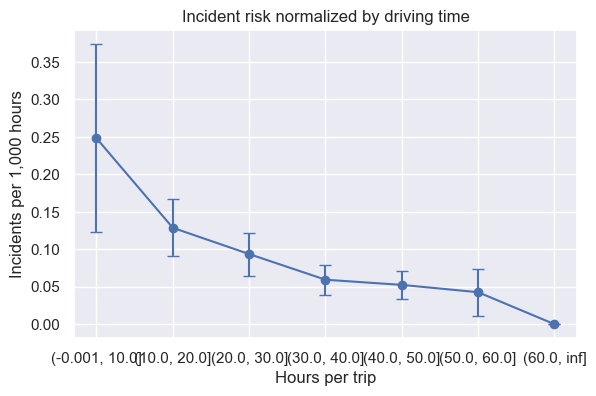

In [93]:
import matplotlib.pyplot as plt

x = hours_exposure.index.astype(str)
y = hours_exposure['inc_p_1000_hours']
yerr = [
    y - hours_exposure['ci_lower_1000h'],
    hours_exposure['ci_upper_1000h'] - y
]

plt.figure(figsize=(6.5, 4))
plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=4)

plt.xlabel('Hours per trip')
plt.ylabel('Incidents per 1,000 hours')
plt.title('Incident risk normalized by driving time')
plt.grid(True)

plt.show()


After normalizing by driving time and accounting for statistical uncertainty, incident risk per hour is highest for short trips and declines steadily as trip duration increases. Confidence intervals confirm that this pattern is not driven by random variation.

In [61]:
share_of_incidents = (
    hours_exposure['incidents'] /
    hours_exposure['incidents'].sum()
)

share_of_hours = (
    hours_exposure['total_hours'] /
    hours_exposure['total_hours'].sum()
)

pd.DataFrame({
    'share_of_incidents': share_of_incidents,
    'share_of_hours': share_of_hours
})


,share_of_incidents,share_of_hours
hours_bin,,
"(-0.001, 10.0]",0.088757,0.028292
"(10.0, 20.0]",0.260355,0.160101
"(20.0, 30.0]",0.242604,0.205011
"(30.0, 40.0]",0.195266,0.260315
"(40.0, 50.0]",0.171598,0.258876
"(50.0, 60.0]",0.041420,0.076800
"(60.0, inf]",0.000000,0.010606


Trips in the 10–20 hour range account for approximately 26% of incidents while representing only 16% of total driving hours, indicating a significant concentration of risk in short-duration operations.

In [62]:
trips = trips_unique.copy()

trips['trip_start'] = pd.to_datetime(trips['dispatch_date'])
trips['trip_end'] = (
    trips['trip_start']
    + pd.to_timedelta(trips['actual_duration_hours'], unit='h')
)



In [63]:
maintenance = (
    maintenance_df
        .drop_duplicates('maintenance_id')
        .copy()
)

maintenance['maintenance_date'] = pd.to_datetime(
    maintenance['maintenance_date']
)


In [64]:
trip_maint = trips.merge(
    maintenance[['maintenance_id', 'truck_id',
                 'maintenance_date', 'downtime_hours']],
    on='truck_id',
    how='left'
)


In [65]:
overlap = (
    (trip_maint['maintenance_date'] >= trip_maint['trip_start']) &
    (trip_maint['maintenance_date'] <= trip_maint['trip_end'])
)

trip_maint = trip_maint[overlap]


In [66]:
downtime_per_trip = (
    trip_maint
        .groupby('trip_id', as_index=False)
        .agg(
            total_downtime_hours=('downtime_hours', 'sum'),
            maintenance_events=('maintenance_id', 'count')
        )
)


In [67]:
trips_with_downtime = trips.merge(
    downtime_per_trip,
    on='trip_id',
    how='left'
)

trips_with_downtime[['total_downtime_hours',
                      'maintenance_events']] = (
    trips_with_downtime[['total_downtime_hours',
                          'maintenance_events']]
        .fillna(0)
)


In [68]:
downtime_by_hours = (
    trips_with_downtime
        .groupby('hours_bin', observed=True)
        .agg(
            trips=('trip_id', 'count'),
            trips_with_downtime=('total_downtime_hours',
                                 lambda x: (x > 0).sum()),
            total_downtime_hours=('total_downtime_hours', 'sum'),
            avg_downtime_per_trip=('total_downtime_hours', 'mean'),
            avg_downtime_if_any=('total_downtime_hours',
                                 lambda x: x[x > 0].mean())
        )
)


In [69]:
downtime_by_hours['dtime_p_1k_drv_hrs'] = (
    downtime_by_hours['total_downtime_hours'] /
    hours_exposure['total_hours'] * 1000
)

downtime_by_hours['pct_trips_with_downtime'] = (
    downtime_by_hours['trips_with_downtime'] /
    downtime_by_hours['trips']
)


In [70]:
downtime_by_hours[
    [
        'trips',
        'pct_trips_with_downtime',
        'avg_downtime_per_trip',
        'avg_downtime_if_any',
        'dtime_p_1k_drv_hrs'
    ]
]


,trips,pct_trips_with_downtime,avg_downtime_per_trip,avg_downtime_if_any,dtime_p_1k_drv_hrs
hours_bin,,,,,
"(-0.001, 10.0]",10868,0.022359,0.566259,25.325514,101.812545
"(10.0, 20.0]",24873,0.021992,0.554613,25.219196,40.329397
"(20.0, 30.0]",17973,0.031492,0.801947,25.465371,32.906765
"(30.0, 40.0]",15737,0.039461,0.963583,24.418519,27.265184
"(40.0, 50.0]",12514,0.044750,1.080997,24.156429,24.458257
"(50.0, 60.0]",3083,0.061953,1.689491,27.270681,31.744261
"(60.0, inf]",362,0.069061,1.630387,23.608000,26.047045


In [71]:
distance_exposure = (
    trips_unique
        .groupby('hours_bin', observed=True)
        .agg(
            total_miles=('actual_distance_miles', 'sum')
        )
)


In [72]:
downtime_by_hours = downtime_by_hours.merge(
    distance_exposure,
    left_index=True,
    right_index=True,
    how='left'
)


In [73]:
downtime_by_hours['downtime_p_1000_miles'] = (
    downtime_by_hours['total_downtime_hours'] /
    downtime_by_hours['total_miles'] * 1000
)


In [74]:
downtime_by_hours[
    [
        'trips',
        'pct_trips_with_downtime',
        'avg_downtime_per_trip',
        'avg_downtime_if_any',
        'dtime_p_1k_drv_hrs',
        'downtime_p_1000_miles'
    ]
]


,trips,pct_trips_with_downtime,avg_downtime_per_trip,avg_downtime_if_any,dtime_p_1k_drv_hrs,downtime_p_1000_miles
hours_bin,,,,,,
"(-0.001, 10.0]",10868,0.022359,0.566259,25.325514,101.812545,1.733367
"(10.0, 20.0]",24873,0.021992,0.554613,25.219196,40.329397,0.699972
"(20.0, 30.0]",17973,0.031492,0.801947,25.465371,32.906765,0.571639
"(30.0, 40.0]",15737,0.039461,0.963583,24.418519,27.265184,0.468392
"(40.0, 50.0]",12514,0.044750,1.080997,24.156429,24.458257,0.433809
"(50.0, 60.0]",3083,0.061953,1.689491,27.270681,31.744261,0.582275
"(60.0, inf]",362,0.069061,1.630387,23.608000,26.047045,0.498557


Even after normalizing by both driving time and distance, short-duration trips experience significantly higher downtime intensity, indicating structurally higher operational fragility.

If downtime per 1,000 miles is:

highest for short trips → downtime is distance-inefficient

flat across bins → downtime is time-driven, not mileage-driven

very high downtime per 1,000 miles in short trips

much lower for long trips

Short trips concentrate disruption both per hour and per mile.

In [75]:
loads_clean = (
    loads_df
        .drop_duplicates('load_id')
        .copy()
)


In [76]:
loads_clean['tot_rev'] = loads_clean['revenue']


In [77]:
loads_clean['tot_rev'] = (
    loads_clean['revenue']
    + loads_clean.get('fuel_surcharge', 0)
    + loads_clean.get('accessorial_charges', 0)
)


In [78]:
trips_with_revenue = (
    trips_unique
        .merge(
            loads_clean[['load_id', 'tot_rev']],
            on='load_id',
            how='left'
        )
)


In [79]:
trips_with_revenue['trip_id'].nunique() == trips_unique['trip_id'].nunique()


True

In [80]:
trips_with_revenue['tot_rev'] = (
    trips_with_revenue['tot_rev'].fillna(0)
)


In [81]:
revenue_by_hours = (
    trips_with_revenue
        .groupby('hours_bin', observed=True)
        .agg(
            trips=('trip_id', 'count'),
            tot_rev=('tot_rev', 'sum'),
            tot_miles=('actual_distance_miles', 'sum'),
            tot_hrs=('actual_duration_hours', 'sum')
        )
)


In [82]:
revenue_by_hours['rev_p_mile'] = (
    revenue_by_hours['tot_rev'] /
    revenue_by_hours['tot_miles']
)

revenue_by_hours['rev_p_hour'] = (
    revenue_by_hours['tot_rev'] /
    revenue_by_hours['tot_hrs']
)


In [91]:
revenue_by_hours['tot_rev'] = revenue_by_hours['tot_rev'].map('{:,.0f}'.format)
downtime_by_hours['dtime_p_1k_drv_hrs'] = downtime_by_hours['dtime_p_1k_drv_hrs'].round(2)
business_case = (
    revenue_by_hours
        .merge(
            hours_exposure[['inc_p_1000_hours']],
            left_index=True, right_index=True
        )
        .merge(
            downtime_by_hours[['dtime_p_1k_drv_hrs']],
            left_index=True, right_index=True
        )
)

business_case


,trips,tot_rev,tot_miles,tot_hrs,rev_p_mile,rev_p_hour,inc_p_1000_hours,dtime_p_1k_drv_hrs
hours_bin,,,,,,,,
"(-0.001, 10.0]",10868,"8,989,245",3550373,60445.4,2.531916,148.716779,0.248158,101.81
"(10.0, 20.0]",24873,"47,186,270",19707775,342055.7,2.394297,137.949084,0.128634,40.33
"(20.0, 30.0]",17973,"62,508,626",25214149,438007.2,2.479109,142.711413,0.093606,32.91
"(30.0, 40.0]",15737,"78,544,181",32374373,556163.5,2.426122,141.224984,0.059335,27.27
"(40.0, 50.0]",12514,"78,816,621",31183280,553089.3,2.527528,142.502524,0.052433,24.46
"(50.0, 60.0]",3083,"20,466,594",8945435,164083.2,2.287937,124.733023,0.042661,31.74
"(60.0, inf]",362,"2,109,891",1183816,22659.0,1.782280,93.114929,0.000000,26.05


In [84]:
business_case[
    [
        'trips',
        'rev_p_mile',
        'rev_p_hour',
        'inc_p_1000_hours',
        'dtime_p_1k_drv_hrs'
    ]
]


,trips,rev_p_mile,rev_p_hour,inc_p_1000_hours,dtime_p_1k_drv_hrs
hours_bin,,,,,
"(-0.001, 10.0]",10868,2.531916,148.716779,0.248158,101.812545
"(10.0, 20.0]",24873,2.394297,137.949084,0.128634,40.329397
"(20.0, 30.0]",17973,2.479109,142.711413,0.093606,32.906765
"(30.0, 40.0]",15737,2.426122,141.224984,0.059335,27.265184
"(40.0, 50.0]",12514,2.527528,142.502524,0.052433,24.458257
"(50.0, 60.0]",3083,2.287937,124.733023,0.042661,31.744261
"(60.0, inf]",362,1.782280,93.114929,0.000000,26.047045


Are we being paid enough for the risk concentration of short trips?